In [1]:
import pandas as pd

ml = pd.read_csv("results/top15_importances.csv")
heatmap = pd.read_csv("results/top20_genes_with_names.csv")

try:
    deg = pd.read_csv("top20_degs_for_annotation.csv")
except:
    deg = None

print("ML columns:", ml.columns)
print("Heatmap columns:", heatmap.columns)

if deg is not None:
    print("DEG columns:", deg.columns)

ML columns: Index(['feature_id', 'gene_symbol', 'importance'], dtype='object')
Heatmap columns: Index(['probe_id', 'gene_name', 'correlation', 'p_value', 'abs_corr',
       'gene_assignment'],
      dtype='object')


In [5]:
print("ML columns:", ml.columns.tolist())
print("Heatmap columns:", heatmap.columns.tolist())

if deg is not None:
    print("DEG columns:", deg.columns.tolist())

ML columns: ['feature_id', 'gene_symbol', 'importance']
Heatmap columns: ['probe_id', 'gene_name', 'correlation', 'p_value', 'abs_corr', 'gene_assignment']


In [7]:
def find_gene_col(df):
    candidates = [
        "gene_symbol", "Gene Symbol", "gene", "Gene", "symbol",
        "SYMBOL", "hgnc_symbol", "HGNC Symbol"
    ]
    for c in candidates:
        if c in df.columns:
            return c
    
    # fallback: first object column
    obj_cols = df.select_dtypes(include="object").columns.tolist()
    if obj_cols:
        return obj_cols[0]
    
    raise ValueError("No suitable gene column found.")

In [9]:
ml_gene_col = find_gene_col(ml)
heatmap_gene_col = find_gene_col(heatmap)

if deg is not None:
    deg_gene_col = find_gene_col(deg)
else:
    deg_gene_col = None

print("ML gene column:", ml_gene_col)
print("Heatmap gene column:", heatmap_gene_col)
print("DEG gene column:", deg_gene_col)

ML gene column: gene_symbol
Heatmap gene column: gene_name
DEG gene column: None


In [11]:
ml_genes = ml[ml_gene_col].astype(str).str.strip()
heatmap_genes = heatmap[heatmap_gene_col].astype(str).str.strip()

if deg is not None:
    deg_genes = deg[deg_gene_col].astype(str).str.strip()
else:
    deg_genes = None

In [15]:
# top ML genes
if "importance" in ml.columns:
    top_ml = (
        ml.sort_values("importance", ascending=False)[ml_gene_col]
        .astype(str).str.strip().head(10)
    )
else:
    top_ml = ml[ml_gene_col].astype(str).str.strip().head(10)

# top heatmap genes
top_heatmap = heatmap[heatmap_gene_col].astype(str).str.strip().head(10)

# top DEG genes
if deg is not None:
    if "padj" in deg.columns:
        top_deg = (
            deg.sort_values("padj", ascending=True)[deg_gene_col]
            .astype(str).str.strip().head(10)
        )
    else:
        top_deg = deg[deg_gene_col].astype(str).str.strip().head(10)
else:
    top_deg = None

print("Top ML genes:", top_ml.tolist())
print("Top Heatmap genes:", top_heatmap.tolist())
if top_deg is not None:
    print("Top DEG genes:", top_deg.tolist())

Top ML genes: ['HLA-DRB5', 'PF4V1', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan']
Top Heatmap genes: ['NM_001099431', 'NM_020244', 'NM_001166116', 'NM_001128829', 'NM_002620', 'NM_000032', 'NM_138445', 'nan', 'NM_080821', 'NM_001207010']


In [17]:
ml_set = set(top_ml)
heatmap_set = set(top_heatmap)

print("Top 1 ML gene:", top_ml.iloc[0])
print("Top 1 Heatmap gene:", top_heatmap.iloc[0])
print("Overlap:", sorted(ml_set.intersection(heatmap_set)))

Top 1 ML gene: HLA-DRB5
Top 1 Heatmap gene: NM_001099431
Overlap: ['nan']


In [19]:
summary = pd.DataFrame({
    "ML_top": pd.Series(top_ml.tolist()),
    "Heatmap_top": pd.Series(top_heatmap.tolist())
})

if top_deg is not None:
    summary["DEG_top"] = pd.Series(top_deg.tolist())

summary

,ML_top,Heatmap_top
0,HLA-DRB5,NM_001099431
1,PF4V1,NM_020244
2,nan,NM_001166116
3,nan,NM_001128829
4,nan,NM_002620
5,nan,NM_000032
6,nan,NM_138445
7,nan,nan
8,nan,NM_080821
9,nan,NM_001207010


In [21]:
print("Heatmap columns:", heatmap.columns.tolist())
print(heatmap.head())

Heatmap columns: ['probe_id', 'gene_name', 'correlation', 'p_value', 'abs_corr', 'gene_assignment']
   probe_id     gene_name  correlation       p_value  abs_corr  \
0   7961102  NM_001099431     0.613054  3.369721e-18  0.613054   
1   7958000     NM_020244     0.571658  1.589759e-15  0.571658   
2   8156706  NM_001166116     0.562609  5.457780e-15  0.562609   
3   8151592  NM_001128829     0.560207  7.525364e-15  0.560207   
4   8095694     NM_002620     0.545923  4.822024e-14  0.545923   

                                     gene_assignment  
0  NM_001099431 // CLEC1B // C-type lectin domain...  
1  NM_020244 // CHPT1 // choline phosphotransfera...  
2  NM_001166116 // TMOD1 // tropomodulin 1 // 9q2...  
3  NM_001128829 // CA1 // carbonic anhydrase I //...  
4  NM_002620 // PF4V1 // platelet factor 4 varian...  


In [23]:
heatmap["gene_symbol"] = (
    heatmap["gene_assignment"]
    .astype(str)
    .str.split(" // ")
    .str[1]
    .str.strip()
)

print(heatmap[["probe_id", "gene_name", "gene_assignment", "gene_symbol"]].head(10))

   probe_id     gene_name                                    gene_assignment  \
0   7961102  NM_001099431  NM_001099431 // CLEC1B // C-type lectin domain...   
1   7958000     NM_020244  NM_020244 // CHPT1 // choline phosphotransfera...   
2   8156706  NM_001166116  NM_001166116 // TMOD1 // tropomodulin 1 // 9q2...   
3   8151592  NM_001128829  NM_001128829 // CA1 // carbonic anhydrase I //...   
4   8095694     NM_002620  NM_002620 // PF4V1 // platelet factor 4 varian...   
5   8173135     NM_000032  NM_000032 // ALAS2 // aminolevulinate, delta-,...   
6   8131067     NM_138445  NM_138445 // GPR146 // G protein-coupled recep...   
7   8180346           NaN                                                ---   
8   8063478     NM_080821  NM_080821 // FAM210B // family with sequence s...   
9   7953901  NM_001207010  NM_001207010 // CLEC12A // C-type lectin domai...   

  gene_symbol  
0      CLEC1B  
1       CHPT1  
2       TMOD1  
3         CA1  
4       PF4V1  
5       ALAS2  
6      

In [25]:
# Remove rows where gene_symbol is missing
heatmap_clean = heatmap.dropna(subset=["gene_symbol"]).copy()

# Get top heatmap genes (already sorted by correlation)
top_heatmap = heatmap_clean["gene_symbol"].head(10)

print("Top Heatmap genes:")
print(top_heatmap.tolist())

Top Heatmap genes:
['CLEC1B', 'CHPT1', 'TMOD1', 'CA1', 'PF4V1', 'ALAS2', 'GPR146', 'FAM210B', 'CLEC12A', 'JAZF1']


In [27]:
# Get top ML genes
top_ml = (
    ml.sort_values("importance", ascending=False)["gene_symbol"]
    .astype(str)
    .str.strip()
    .head(10)
)

print("Top ML genes:")
print(top_ml.tolist())

Top ML genes:
['HLA-DRB5', 'PF4V1', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan', 'nan']


In [29]:
# Clean ML gene list
top_ml_clean = (
    ml.sort_values("importance", ascending=False)["gene_symbol"]
    .replace("nan", pd.NA)   # fix string "nan"
    .dropna()
    .astype(str)
    .str.strip()
    .head(10)
)

print("Clean Top ML genes:")
print(top_ml_clean.tolist())

Clean Top ML genes:
['HLA-DRB5', 'PF4V1', 'GLRX5', 'RPS26P11']


In [31]:
# Top 1 comparison
top1_ml = top_ml_clean.iloc[0]
top1_heatmap = top_heatmap.iloc[0]

print("Top 1 ML gene:", top1_ml)
print("Top 1 Heatmap gene:", top1_heatmap)

# Overlap
overlap = set(top_ml_clean).intersection(set(top_heatmap))

print("\nOverlap genes:")
print(list(overlap))

Top 1 ML gene: HLA-DRB5
Top 1 Heatmap gene: CLEC1B

Overlap genes:
['PF4V1']


In [33]:
# Combine both lists
combined = pd.DataFrame({
    "ML_genes": pd.Series(top_ml_clean.tolist()),
    "Heatmap_genes": pd.Series(top_heatmap.tolist())
})

# Create unified set
all_genes = list(set(top_ml_clean).union(set(top_heatmap)))

# Create final summary table
final_table = pd.DataFrame({
    "gene_symbol": all_genes,
    "in_ML": [g in set(top_ml_clean) for g in all_genes],
    "in_Heatmap": [g in set(top_heatmap) for g in all_genes]
})

# Sort so overlapping genes come first
final_table["score"] = final_table["in_ML"].astype(int) + final_table["in_Heatmap"].astype(int)
final_table = final_table.sort_values("score", ascending=False)

print(final_table)

   gene_symbol  in_ML  in_Heatmap  score
11       PF4V1   True        True      2
0        GLRX5   True       False      1
1      CLEC12A  False        True      1
2       GPR146  False        True      1
3        TMOD1  False        True      1
4      FAM210B  False        True      1
5     RPS26P11   True       False      1
6        ALAS2  False        True      1
7        JAZF1  False        True      1
8          CA1  False        True      1
9     HLA-DRB5   True       False      1
10      CLEC1B  False        True      1
12       CHPT1  False        True      1


In [35]:
# Select top consistent genes (you can adjust count)
final_genes = final_table["gene_symbol"].head(10).tolist()

print("Final genes used for all plots:")
print(final_genes)

Final genes used for all plots:
['PF4V1', 'GLRX5', 'CLEC12A', 'GPR146', 'TMOD1', 'FAM210B', 'RPS26P11', 'ALAS2', 'JAZF1', 'CA1']


In [41]:
print(expr.head())
print(expr.columns.tolist())

    ID_REF  GSM2600155  GSM2600156  GSM2600157  GSM2600158  GSM2600159  \
0  7896742    7.609771    7.548369    6.904948    7.419922    7.211682   
1  7896746    8.011875    9.459939    8.914414    8.952370    9.170796   
2  7896748    4.970357    6.406132    6.344124    6.233006    6.628693   
3  7896750    4.681245    5.783345    4.771276    5.150634    5.627720   
4  7896752    8.864139    9.613436    9.096668    9.185180    9.565067   

   GSM2600160  GSM2600161  GSM2600162  GSM2600163  ...  GSM2600308  \
0    7.514782    7.180663    6.632171    7.037950  ...    8.037015   
1    8.824364    8.938188    8.547712    9.201392  ...    8.938188   
2    6.255561    6.117289    6.213465    5.744869  ...    6.387389   
3    4.956121    5.272383    4.626317    4.723753  ...    4.984447   
4    9.249295    9.352002    8.922792    8.980686  ...    8.947175   

   GSM2600309  GSM2600310  GSM2600311  GSM2600312  GSM2600313  GSM2600314  \
0    8.043108    7.821693    7.721724    7.990820    7.83

In [43]:
# Make mapping key match expression key
mapping = heatmap[["probe_id", "gene_symbol"]].dropna().copy()
mapping["probe_id"] = mapping["probe_id"].astype(str)

expr["ID_REF"] = expr["ID_REF"].astype(str)

# Merge expression with gene symbols
expr_mapped = expr.merge(
    mapping,
    left_on="ID_REF",
    right_on="probe_id",
    how="left"
)

print(expr_mapped[["ID_REF", "probe_id", "gene_symbol"]].head(10))
print(expr_mapped.shape)

    ID_REF probe_id gene_symbol
0  7896742      NaN         NaN
1  7896746      NaN         NaN
2  7896748      NaN         NaN
3  7896750      NaN         NaN
4  7896752      NaN         NaN
5  7896817      NaN         NaN
6  7896878      NaN         NaN
7  7897006      NaN         NaN
8  7897068      NaN         NaN
9  7897078      NaN         NaN
(8506, 166)


In [47]:
print("Example expression IDs:")
print(expr["ID_REF"].astype(str).head(10).tolist())

print("\nExample heatmap probe IDs:")
print(heatmap["probe_id"].astype(str).head(10).tolist())

# Load the full mapping file instead of the heatmap-derived mapping
mapping_full = pd.read_csv("results/mapped_all_gene_symbols.csv")
print("\nMapping file columns:")
print(mapping_full.columns.tolist())
print(mapping_full.head())

Example expression IDs:
['7896742', '7896746', '7896748', '7896750', '7896752', '7896817', '7896878', '7897006', '7897068', '7897078']

Example heatmap probe IDs:
['7961102', '7958000', '8156706', '8151592', '8095694', '8173135', '8131067', '8180346', '8063478', '7953901']

Mapping file columns:
['gene_symbol']
            gene_symbol
0    chr16213092-215155
1    chr16215973-216767
2  chr219907193-9968585
3   chr46694796-6698897
4   chr71084243-1098897


In [49]:
# Check whether there is any overlap at all between expression IDs and heatmap probe IDs
expr_ids = set(expr["ID_REF"].astype(str))
heatmap_ids = set(heatmap["probe_id"].astype(str))

overlap_ids = expr_ids.intersection(heatmap_ids)

print("Number of expression IDs:", len(expr_ids))
print("Number of heatmap probe IDs:", len(heatmap_ids))
print("Number of overlapping IDs:", len(overlap_ids))

# Show a few overlaps if they exist
print("Sample overlapping IDs:", list(overlap_ids)[:10])

Number of expression IDs: 8506
Number of heatmap probe IDs: 20
Number of overlapping IDs: 20
Sample overlapping IDs: ['8063478', '8007462', '7953977', '8095694', '8180346', '7961102', '8092552', '8131067', '7989849', '8138789']


In [53]:
# Make both merge keys the same type first
expr_sub["ID_REF"] = expr_sub["ID_REF"].astype(str)

heatmap_merge = heatmap[["probe_id", "gene_symbol"]].copy()
heatmap_merge["probe_id"] = heatmap_merge["probe_id"].astype(str)

# merge using matching string keys
expr_mapped = expr_sub.merge(
    heatmap_merge,
    left_on="ID_REF",
    right_on="probe_id",
    how="left"
)

print(expr_mapped[["ID_REF", "probe_id", "gene_symbol"]].head(10))
print(expr_mapped.shape)

    ID_REF probe_id gene_symbol
0  7930398  7930398        MXI1
1  7953901  7953901     CLEC12A
2  7953977  7953977         NaN
3  7958000  7958000       CHPT1
4  7958262  7958262     TCP11L2
5  7961102  7961102      CLEC1B
6  7989849  7989849     DENND4A
7  8007462  8007462        NBR2
8  8018097  8018097     FAM104A
9  8058221  8058221       TRAK2
(20, 166)


In [55]:
expr_final = expr_mapped[expr_mapped["gene_symbol"].isin(final_genes)].copy()

# Set gene symbols as row labels
expr_final = expr_final.set_index("gene_symbol")

# Drop ID columns
expr_final = expr_final.drop(columns=["ID_REF", "probe_id"])

print(expr_final.shape)
print(expr_final.index.tolist())

(8, 163)
['CLEC12A', 'FAM210B', 'PF4V1', 'GPR146', 'JAZF1', 'CA1', 'TMOD1', 'ALAS2']


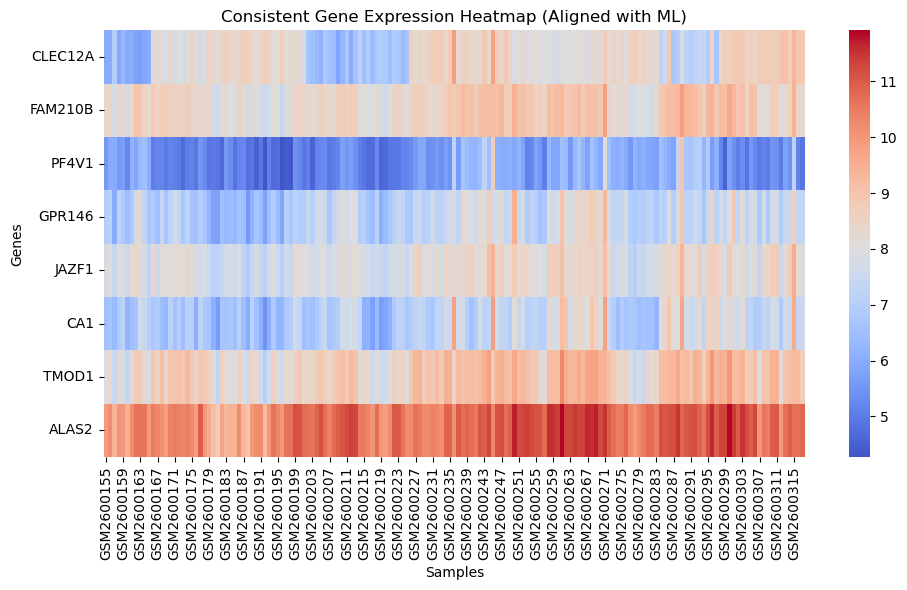

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.heatmap(
    expr_final,
    cmap="coolwarm",
    center=expr_final.values.mean(),
    yticklabels=True
)

plt.title("Consistent Gene Expression Heatmap (Aligned with ML)")
plt.xlabel("Samples")
plt.ylabel("Genes")

plt.tight_layout()
plt.show()

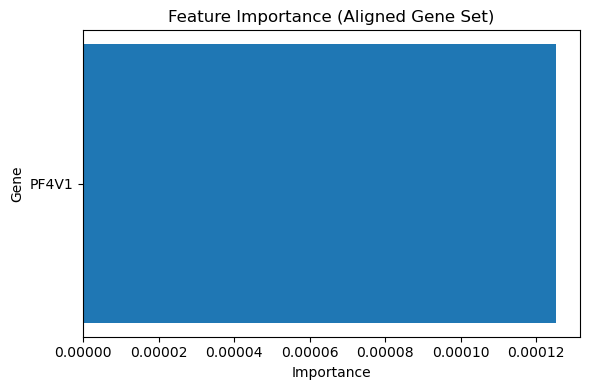

In [59]:
ml_final = ml[ml["gene_symbol"].isin(expr_final.index)].copy()
ml_final = ml_final.sort_values("importance", ascending=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.barh(ml_final["gene_symbol"], ml_final["importance"])
plt.gca().invert_yaxis()

plt.title("Feature Importance (Aligned Gene Set)")
plt.xlabel("Importance")
plt.ylabel("Gene")

plt.tight_layout()
plt.show()

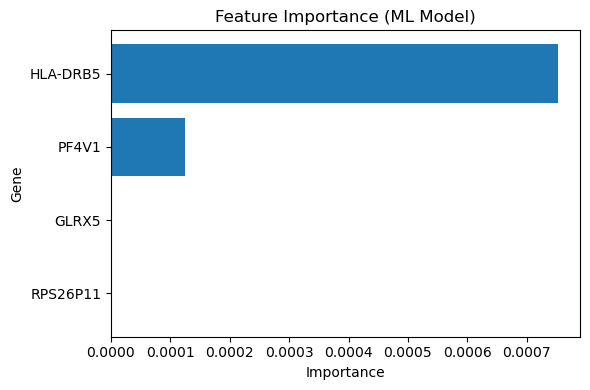

In [63]:
ml_clean = (
    ml.sort_values("importance", ascending=False)
    .dropna(subset=["gene_symbol"])
)

plt.figure(figsize=(6,4))

plt.barh(ml_clean["gene_symbol"], ml_clean["importance"])
plt.gca().invert_yaxis()

plt.title("Feature Importance (ML Model)")
plt.xlabel("Importance")
plt.ylabel("Gene")

plt.tight_layout()
plt.show()

In [65]:
# Get HLA-DRB5 rows from mapped expression
hla_data = expr_mapped[expr_mapped["gene_symbol"] == "HLA-DRB5"].copy()

print(hla_data.shape)
print(hla_data.head())

(0, 166)
Empty DataFrame
Columns: [ID_REF, GSM2600155, GSM2600156, GSM2600157, GSM2600158, GSM2600159, GSM2600160, GSM2600161, GSM2600162, GSM2600163, GSM2600164, GSM2600165, GSM2600166, GSM2600167, GSM2600168, GSM2600169, GSM2600170, GSM2600171, GSM2600172, GSM2600173, GSM2600174, GSM2600175, GSM2600176, GSM2600177, GSM2600178, GSM2600179, GSM2600180, GSM2600181, GSM2600182, GSM2600183, GSM2600184, GSM2600185, GSM2600186, GSM2600187, GSM2600188, GSM2600189, GSM2600190, GSM2600191, GSM2600192, GSM2600193, GSM2600194, GSM2600195, GSM2600196, GSM2600197, GSM2600198, GSM2600199, GSM2600200, GSM2600201, GSM2600202, GSM2600203, GSM2600204, GSM2600205, GSM2600206, GSM2600207, GSM2600208, GSM2600209, GSM2600210, GSM2600211, GSM2600212, GSM2600213, GSM2600214, GSM2600215, GSM2600216, GSM2600217, GSM2600218, GSM2600219, GSM2600220, GSM2600221, GSM2600222, GSM2600223, GSM2600224, GSM2600225, GSM2600226, GSM2600227, GSM2600228, GSM2600229, GSM2600230, GSM2600231, GSM2600232, GSM2600233, GSM260023

In [67]:
# Search for anything related to HLA in your mapped data
hla_search = expr_mapped[expr_mapped["gene_symbol"].str.contains("HLA", na=False)]

print(hla_search[["gene_symbol"]].drop_duplicates())

Empty DataFrame
Columns: [gene_symbol]
Index: []


In [69]:
print(ml.head())

   feature_id gene_symbol  importance
0     8125436    HLA-DRB5    0.000752
1     8095694       PF4V1    0.000125
2     8089928         NaN    0.000125
3     7958000         NaN    0.000000
4     8047443         NaN    0.000000


In [71]:
print(ml[["feature_id", "gene_symbol"]])

    feature_id gene_symbol
0      8125436    HLA-DRB5
1      8095694       PF4V1
2      8089928         NaN
3      7958000         NaN
4      8047443         NaN
5      8019641         NaN
6      8019639         NaN
7      8019637         NaN
8      8019635         NaN
9      8019631         NaN
10     7901336         NaN
11     8169709       GLRX5
12     8154363    RPS26P11
13     8165496         NaN
14     7909283         NaN


In [73]:
# Get the probe ID for HLA-DRB5 from ML
hla_probe = ml.loc[ml["gene_symbol"] == "HLA-DRB5", "feature_id"].astype(str).values[0]

print("HLA probe ID:", hla_probe)

# Extract expression row directly using ID_REF
hla_expr = expr[expr["ID_REF"].astype(str) == hla_probe].copy()

print(hla_expr.shape)
print(hla_expr.head())

HLA probe ID: 8125436
(1, 164)
       ID_REF  GSM2600155  GSM2600156  GSM2600157  GSM2600158  GSM2600159  \
6770  8125436    5.262719    5.777416    5.168359    5.383778    5.248391   

      GSM2600160  GSM2600161  GSM2600162  GSM2600163  ...  GSM2600308  \
6770    5.108321    5.490291    5.522146    5.375338  ...    5.333732   

      GSM2600309  GSM2600310  GSM2600311  GSM2600312  GSM2600313  GSM2600314  \
6770    5.734544    5.554749    5.554369    5.418924    5.952069    5.610033   

      GSM2600315  GSM2600316  GSM2600317  
6770     5.71703    5.568209    5.443812  

[1 rows x 164 columns]


In [79]:
# Inspect metadata columns so we can merge using the correct sample column
print(meta.columns.tolist())
print(meta.head())

['sample_id', 'title', 'source', 'characteristics', 'condition']
    sample_id                                          title source  \
0  GSM2600155  Control subject 6045 blood collection 01 [D9]  blood   
1  GSM2600156  Control subject 6045 blood collection 02 [D9]  blood   
2  GSM2600157  Control subject 6045 blood collection 03 [D9]  blood   
3  GSM2600158  Control subject 6045 blood collection 04 [D9]  blood   
4  GSM2600159  Control subject 6045 blood collection 08 [D9]  blood   

  characteristics     condition  
0  timepoint: t01  normal_sleep  
1  timepoint: t02  normal_sleep  
2  timepoint: t03  normal_sleep  
3  timepoint: t04  normal_sleep  
4  timepoint: t05  normal_sleep  


In [83]:
# Merge using the correct metadata sample column
hla_long = hla_long.merge(meta, left_on="sample", right_on="sample_id", how="left")

print(hla_long.head())
print(hla_long.shape)
print(hla_long["condition"].value_counts(dropna=False))

    ID_REF      sample  expression   sample_id  \
0  8125436  GSM2600155    5.262719  GSM2600155   
1  8125436  GSM2600156    5.777416  GSM2600156   
2  8125436  GSM2600157    5.168359  GSM2600157   
3  8125436  GSM2600158    5.383778  GSM2600158   
4  8125436  GSM2600159    5.248391  GSM2600159   

                                           title source characteristics  \
0  Control subject 6045 blood collection 01 [D9]  blood  timepoint: t01   
1  Control subject 6045 blood collection 02 [D9]  blood  timepoint: t02   
2  Control subject 6045 blood collection 03 [D9]  blood  timepoint: t03   
3  Control subject 6045 blood collection 04 [D9]  blood  timepoint: t04   
4  Control subject 6045 blood collection 08 [D9]  blood  timepoint: t05   

      condition  
0  normal_sleep  
1  normal_sleep  
2  normal_sleep  
3  normal_sleep  
4  normal_sleep  
(163, 8)
condition
sleep_deprived    92
normal_sleep      71
Name: count, dtype: int64


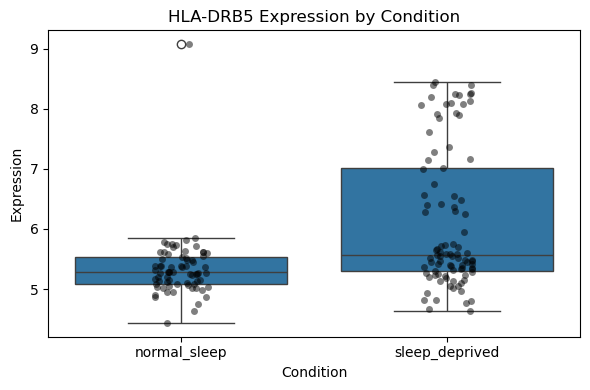

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.boxplot(
    data=hla_long,
    x="condition",
    y="expression"
)

sns.stripplot(
    data=hla_long,
    x="condition",
    y="expression",
    color="black",
    alpha=0.5
)

plt.title("HLA-DRB5 Expression by Condition")
plt.xlabel("Condition")
plt.ylabel("Expression")

plt.tight_layout()
plt.show()

In [87]:
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression

# Prepare data
X = hla_long[["expression"]].values
y = (hla_long["condition"] == "sleep_deprived").astype(int).values

# Train simple model
model = LogisticRegression()
model.fit(X, y)

# Predict probabilities
y_pred = model.predict_proba(X)[:, 1]

# Compute AUC
auc = roc_auc_score(y, y_pred)

print("AUC using only HLA-DRB5:", auc)

AUC using only HLA-DRB5: 0.7015462339252909


In [89]:
# Get PF4V1 expression (same way as HLA)
pf4_probe = ml.loc[ml["gene_symbol"] == "PF4V1", "feature_id"].astype(str).values[0]

pf4_expr = expr[expr["ID_REF"].astype(str) == pf4_probe].copy()

# reshape
pf4_long = pf4_expr.melt(id_vars=["ID_REF"], var_name="sample", value_name="pf4_expression")

# merge with metadata
pf4_long = pf4_long.merge(meta, left_on="sample", right_on="sample_id")

# merge HLA + PF4
scatter_df = hla_long.merge(
    pf4_long[["sample", "pf4_expression"]],
    on="sample"
)

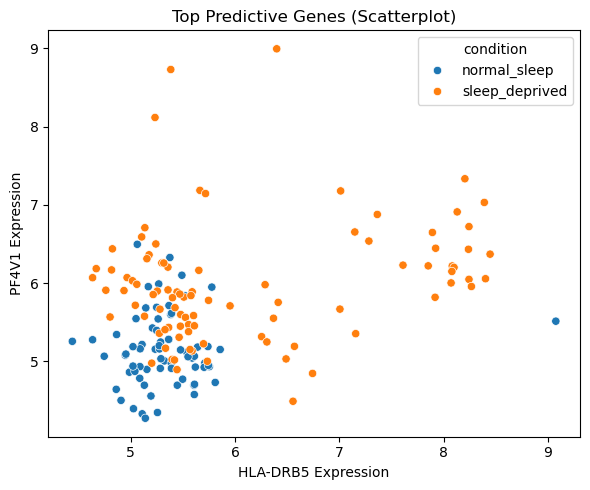

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.scatterplot(
    data=scatter_df,
    x="expression",
    y="pf4_expression",
    hue="condition"
)

plt.xlabel("HLA-DRB5 Expression")
plt.ylabel("PF4V1 Expression")
plt.title("Top Predictive Genes (Scatterplot)")

plt.tight_layout()
plt.show()

In [93]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

ml_clean = (
    ml.dropna(subset=["gene_symbol"])
    .sort_values("importance", ascending=False)
)

top_genes = ml_clean["gene_symbol"].tolist()

print("Top genes:", top_genes)

gene_expr_list = []

for gene in top_genes:
    probe = ml.loc[ml["gene_symbol"] == gene, "feature_id"].astype(str).values[0]
    temp = expr[expr["ID_REF"].astype(str) == probe].copy()
    temp = temp.melt(id_vars=["ID_REF"], var_name="sample", value_name=gene)
    gene_expr_list.append(temp[["sample", gene]])

# Merge all genes into one dataframe
from functools import reduce
X_df = reduce(lambda left, right: left.merge(right, on="sample"), gene_expr_list)

# Add labels
X_df = X_df.merge(meta, left_on="sample", right_on="sample_id")

# Target
y = (X_df["condition"] == "sleep_deprived").astype(int).values

Top genes: ['HLA-DRB5', 'PF4V1', 'GLRX5', 'RPS26P11']


In [95]:
auc_scores = []

for i in range(1, len(top_genes) + 1):
    selected_genes = top_genes[:i]
    
    X = X_df[selected_genes].values
    
    model = LogisticRegression(max_iter=1000)
    model.fit(X, y)
    
    y_pred = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, y_pred)
    
    auc_scores.append(auc)

print("AUC progression:", auc_scores)

AUC progression: [0.7015462339252909, 0.8845682792406613, 0.8981935088793632, 0.9634109001837109]


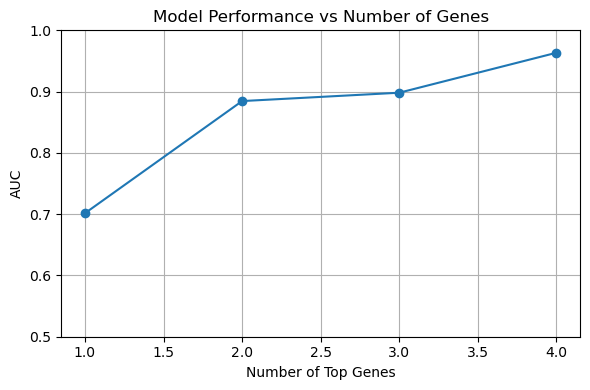

In [97]:
plt.figure(figsize=(6,4))

plt.plot(range(1, len(auc_scores)+1), auc_scores, marker='o')

plt.xlabel("Number of Top Genes")
plt.ylabel("AUC")
plt.title("Model Performance vs Number of Genes")

plt.ylim(0.5, 1.0)
plt.grid(True)

plt.tight_layout()
plt.show()

In [99]:
# Get top 10 features (NOT just mapped genes)
top_features = ml.sort_values("importance", ascending=False)["feature_id"].astype(str).tolist()[:10]

print("Top feature IDs:", top_features)

Top feature IDs: ['8125436', '8095694', '8089928', '7958000', '8047443', '8019641', '8019639', '8019637', '8019635', '8019631']


In [101]:
feature_expr_list = []

for feat in top_features:
    temp = expr[expr["ID_REF"].astype(str) == feat].copy()
    temp = temp.melt(id_vars=["ID_REF"], var_name="sample", value_name=feat)
    feature_expr_list.append(temp[["sample", feat]])

from functools import reduce
X_df = reduce(lambda left, right: left.merge(right, on="sample"), feature_expr_list)

# Add labels
X_df = X_df.merge(meta, left_on="sample", right_on="sample_id")

y = (X_df["condition"] == "sleep_deprived").astype(int).values

In [103]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

auc_scores = []

for i in range(1, len(top_features) + 1):
    selected = top_features[:i]
    X = X_df[selected].values
    
    model = LogisticRegression(max_iter=1000)
    model.fit(X, y)
    
    y_pred = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, y_pred)
    
    auc_scores.append(auc)

print(auc_scores)

[0.7015462339252909, 0.8845682792406613, 0.9151867728107778, 0.9277403551745254, 0.9275872627066749, 0.9427434170238825, 0.942896509491733, 0.9424372320881813, 0.9425903245560319, 0.9421310471524801]


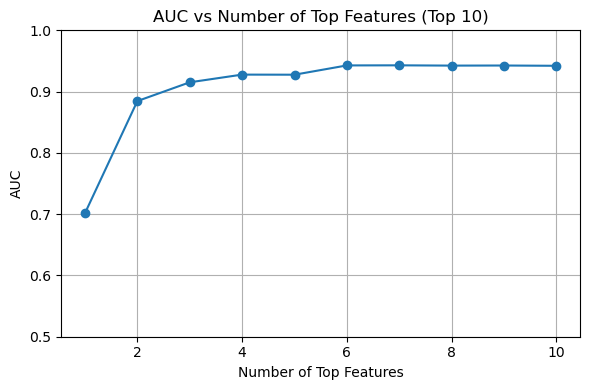

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(range(1, len(auc_scores)+1), auc_scores, marker='o')

plt.xlabel("Number of Top Features")
plt.ylabel("AUC")
plt.title("AUC vs Number of Top Features (Top 10)")

plt.ylim(0.5, 1.0)
plt.grid(True)

plt.tight_layout()
plt.show()

In [107]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Use your X_df from before (top features)
features = top_features[:4]   # you can try 2, 4, 6 etc.

X = X_df[features].values
y = (X_df["condition"] == "sleep_deprived").astype(int).values

model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)
model.fit(X, y)

y_pred = model.predict_proba(X)[:, 1]
auc = roc_auc_score(y, y_pred)

print("AUC:", auc)
print("Coefficients:", model.coef_)

AUC: 0.9277403551745254
Coefficients: [[ 0.70371664  1.57806004 -1.9311188   1.60458613]]


In [109]:
import numpy as np

C_values = [0.01, 0.1, 1, 10, 100]
results = []

for C in C_values:
    model = LogisticRegression(penalty='l2', C=C, max_iter=1000)
    model.fit(X, y)
    
    y_pred = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, y_pred)
    
    results.append((C, auc))

print(results)

[(0.01, 0.9177893447642376), (0.1, 0.9216166564605022), (1, 0.9277403551745254), (10, 0.9274341702388242), (100, 0.9274341702388242)]


In [111]:
coef_df = pd.DataFrame({
    "gene": features,
    "coefficient": model.coef_[0]
})

print(coef_df.sort_values(by="coefficient", ascending=False))

      gene  coefficient
3  7958000     2.477436
1  8095694     1.816922
0  8125436     0.716976
2  8089928    -2.778055


In [113]:
import statsmodels.api as sm

X_sm = sm.add_constant(X_df[features])
model_sm = sm.Logit(y, X_sm).fit()

print(model_sm.summary())

Optimization terminated successfully.
         Current function value: 0.343366
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  163
Model:                          Logit   Df Residuals:                      158
Method:                           MLE   Df Model:                            4
Date:                Tue, 24 Mar 2026   Pseudo R-squ.:                  0.4986
Time:                        21:23:18   Log-Likelihood:                -55.969
converged:                       True   LL-Null:                       -111.63
Covariance Type:            nonrobust   LLR p-value:                 3.814e-23
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.5911     11.105     -0.503      0.615     -27.356      16.174
8125436        0.7170      0.

In [115]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = []

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    
    y_pred = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred)
    
    auc_scores.append(auc)

print("Cross-validated AUC:", np.mean(auc_scores), "+/-", np.std(auc_scores))

Cross-validated AUC: 0.9270064049011417 +/- 0.03923220568760728


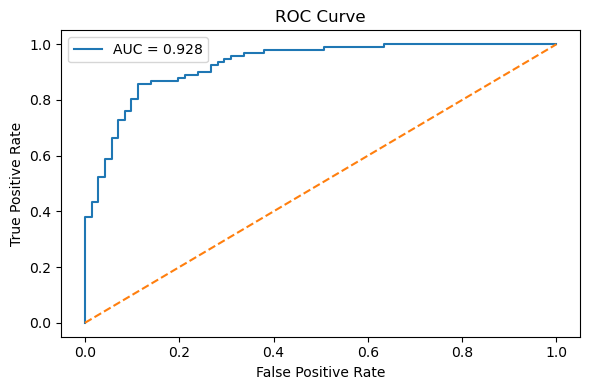

In [121]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

features = top_features[:4]   

# Build X and y from the same dataframe
X = X_df[features].values
y = (X_df["condition"] == "sleep_deprived").astype(int).values

# Fit model
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# Predict probabilities on the SAME X
y_pred = model.predict_proba(X)[:, 1]

# ROC + AUC
fpr, tpr, _ = roc_curve(y, y_pred)
auc = roc_auc_score(y, y_pred)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

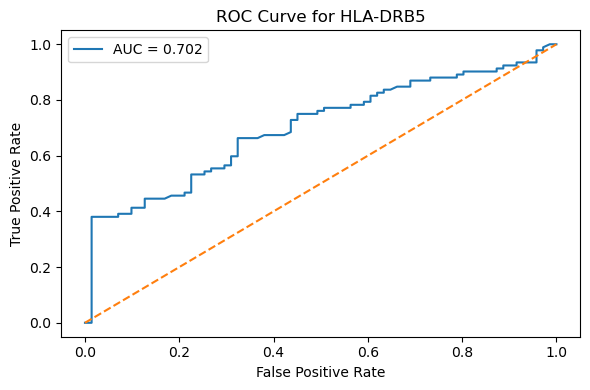

In [123]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

X = hla_long[["expression"]].values
y = (hla_long["condition"] == "sleep_deprived").astype(int).values

model = LogisticRegression(max_iter=1000)
model.fit(X, y)
y_pred = model.predict_proba(X)[:, 1]

fpr, tpr, _ = roc_curve(y, y_pred)
auc = roc_auc_score(y, y_pred)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for HLA-DRB5")
plt.legend()
plt.tight_layout()
plt.show()

In [133]:
expr_final.index.name = "gene_symbol"

['CLEC12A', 'FAM210B', 'PF4V1', 'GPR146', 'JAZF1', 'CA1', 'TMOD1', 'ALAS2']


<Figure size 1000x600 with 0 Axes>

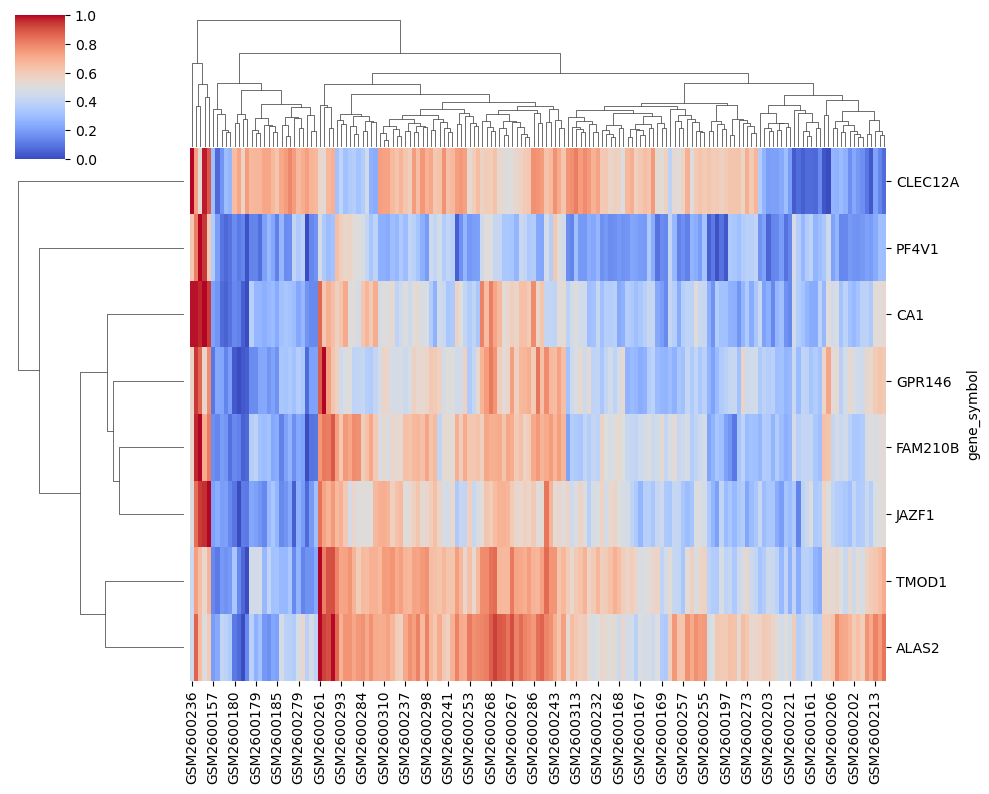

In [137]:
import seaborn as sns
import matplotlib.pyplot as plt

print(expr_final.index.tolist())  # sanity check

# Plot heatmap
plt.figure(figsize=(10,6))

sns.clustermap(
    expr_final,
    cmap="coolwarm",
    standard_scale=0,
    figsize=(10,8),
    yticklabels=True
)

plt.show()

In [127]:
import numpy as np

coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])
print(coef_df)

      gene  coefficient  odds_ratio
0  8125436     0.716976    2.048229
1  8095694     1.816922    6.152890
2  8089928    -2.778055    0.062159
3  7958000     2.477436   11.910685


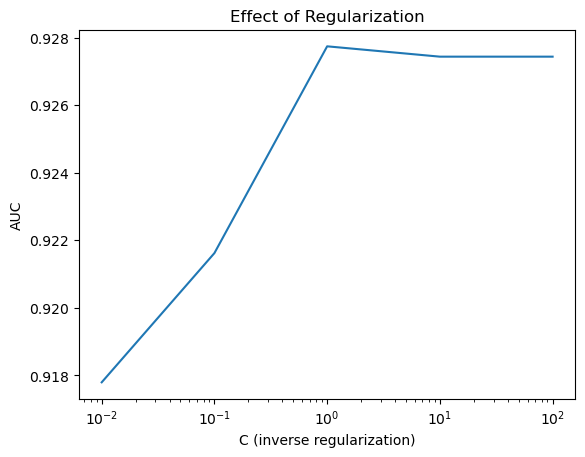

In [129]:
plt.plot([r[0] for r in results], [r[1] for r in results])
plt.xscale("log")
plt.xlabel("C (inverse regularization)")
plt.ylabel("AUC")
plt.title("Effect of Regularization")
plt.show()

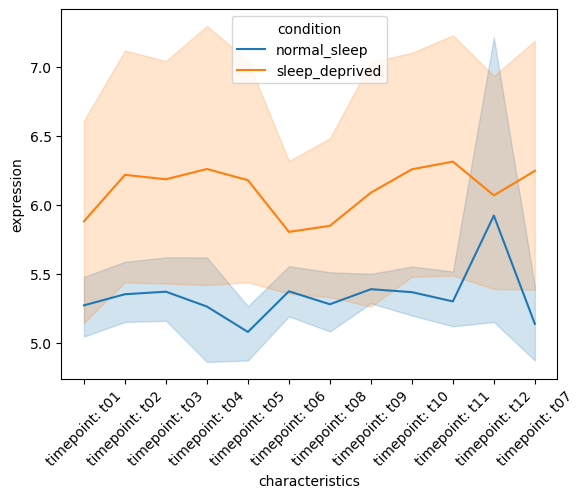

In [131]:
sns.lineplot(data=hla_long, x="characteristics", y="expression", hue="condition")
plt.xticks(rotation=45)
plt.show()

In [139]:
meta.groupby("condition")["characteristics"].unique()

condition
normal_sleep      [timepoint: t01, timepoint: t02, timepoint: t0...
sleep_deprived    [timepoint: t01, timepoint: t02, timepoint: t0...
Name: characteristics, dtype: object

In [141]:
import pandas as pd

# expression matrix
expr = pd.read_csv("results/normalized_expression.csv")

# metadata
meta = pd.read_csv("results/sample_metadata.csv")

print(expr.shape)
print(meta.shape)
print(meta.head())

(8506, 164)
(163, 5)
    sample_id                                          title source  \
0  GSM2600155  Control subject 6045 blood collection 01 [D9]  blood   
1  GSM2600156  Control subject 6045 blood collection 02 [D9]  blood   
2  GSM2600157  Control subject 6045 blood collection 03 [D9]  blood   
3  GSM2600158  Control subject 6045 blood collection 04 [D9]  blood   
4  GSM2600159  Control subject 6045 blood collection 08 [D9]  blood   

  characteristics     condition  
0  timepoint: t01  normal_sleep  
1  timepoint: t02  normal_sleep  
2  timepoint: t03  normal_sleep  
3  timepoint: t04  normal_sleep  
4  timepoint: t05  normal_sleep  


In [145]:
cases_meta = meta[meta["condition"] == "sleep_deprived"].copy()

print(cases_meta.shape)
print(cases_meta.head(10))
print(cases_meta["characteristics"].value_counts().sort_index())

(92, 5)
     sample_id                                              title source  \
71  GSM2600226  Sleep deprived subject 6166 blood collection 0...  blood   
72  GSM2600227  Sleep deprived subject 6166 blood collection 0...  blood   
73  GSM2600228  Sleep deprived subject 6166 blood collection 0...  blood   
74  GSM2600229  Sleep deprived subject 6166 blood collection 0...  blood   
75  GSM2600230  Sleep deprived subject 6166 blood collection 0...  blood   
76  GSM2600231  Sleep deprived subject 6166 blood collection 0...  blood   
77  GSM2600232  Sleep deprived subject 6166 blood collection 1...  blood   
78  GSM2600233  Sleep deprived subject 6166 blood collection 1...  blood   
79  GSM2600234  Sleep deprived subject 6166 blood collection 1...  blood   
80  GSM2600235  Sleep deprived subject 6166 blood collection 1...  blood   

   characteristics       condition  
71  timepoint: t01  sleep_deprived  
72  timepoint: t02  sleep_deprived  
73  timepoint: t03  sleep_deprived  
74  tim

In [147]:
# Extract timepoint number
cases_meta["timepoint"] = cases_meta["characteristics"].str.extract(r't(\d+)').astype(int)

# Define phases
baseline_meta = cases_meta[cases_meta["timepoint"] <= 4].copy()
deprived_meta = cases_meta[cases_meta["timepoint"] >= 5].copy()

print("Baseline samples:", baseline_meta.shape)
print("Sleep deprivation samples:", deprived_meta.shape)

print("Baseline timepoints:", baseline_meta["timepoint"].unique())
print("Deprivation timepoints:", deprived_meta["timepoint"].unique())

Baseline samples: (29, 6)
Sleep deprivation samples: (63, 6)
Baseline timepoints: [1 2 3 4]
Deprivation timepoints: [ 5  6  7  8  9 10 11 12]


In [149]:
# Get sample IDs
baseline_samples = baseline_meta["sample_id"].tolist()
deprived_samples = deprived_meta["sample_id"].tolist()

# Subset expression data
baseline_expr = expr[["ID_REF"] + baseline_samples].copy()
deprived_expr = expr[["ID_REF"] + deprived_samples].copy()

print(baseline_expr.shape)
print(deprived_expr.shape)

(8506, 30)
(8506, 64)


In [151]:
from scipy.stats import ttest_ind
import numpy as np

# Compute mean expression in each group
baseline_mean = baseline_expr.drop(columns=["ID_REF"]).mean(axis=1)
deprived_mean = deprived_expr.drop(columns=["ID_REF"]).mean(axis=1)

# Compute log2 fold change
log2fc = np.log2(deprived_mean + 1e-8) - np.log2(baseline_mean + 1e-8)

# Row-wise t-test
pvals = []
for i in range(expr.shape[0]):
    b = baseline_expr.drop(columns=["ID_REF"]).iloc[i].values
    d = deprived_expr.drop(columns=["ID_REF"]).iloc[i].values
    _, p = ttest_ind(d, b, equal_var=False, nan_policy="omit")
    pvals.append(p)

deg_results = pd.DataFrame({
    "ID_REF": expr["ID_REF"].astype(str),
    "baseline_mean": baseline_mean,
    "deprived_mean": deprived_mean,
    "log2FC": log2fc,
    "p_value": pvals
})

print(deg_results.head())

    ID_REF  baseline_mean  deprived_mean    log2FC   p_value
0  7896742       7.526555       7.378966 -0.028571  0.208402
1  7896746       8.730205       8.839779  0.017995  0.370626
2  7896748       5.912015       6.147866  0.056436  0.308837
3  7896750       4.945330       5.142158  0.056307  0.299560
4  7896752       9.092990       9.161999  0.010908  0.568421


In [153]:
from statsmodels.stats.multitest import multipletests

# Adjust p-values (FDR)
deg_results["adj_p"] = multipletests(deg_results["p_value"], method="fdr_bh")[1]

# Add significance flag
deg_results["significant"] = (deg_results["adj_p"] < 0.05) & (abs(deg_results["log2FC"]) > 0.1)

# Sort by adjusted p-value
deg_results = deg_results.sort_values("adj_p")

print(deg_results.head(10))

# Count significant genes
print("Number of significant DEGs:", deg_results["significant"].sum())

       ID_REF  baseline_mean  deprived_mean    log2FC   p_value     adj_p  \
2727  7990417      10.029642       9.820300 -0.030431  0.021808  0.512042   
1523  7948399       7.973816       7.844137 -0.023656  0.018147  0.512042   
1522  7948379       5.898081       5.785447 -0.027817  0.011129  0.512042   
5269  8073397       5.663506       5.765759  0.025815  0.011877  0.512042   
5283  8074061       5.636048       5.813585  0.044744  0.013240  0.512042   
5298  8074688       6.016294       6.141667  0.029755  0.025875  0.512042   
5300  8074791       8.584965       8.471201 -0.019246  0.027116  0.512042   
5314  8075239       6.911456       6.759330 -0.032109  0.025062  0.512042   
5338  8075910      10.454150      10.271181 -0.025474  0.011306  0.512042   
7490  8149264       6.738906       6.507208 -0.050476  0.023919  0.512042   

      significant  
2727        False  
1523        False  
1522        False  
5269        False  
5283        False  
5298        False  
5300        

In [155]:
# Extract timepoint number for ALL samples
meta["timepoint"] = meta["characteristics"].str.extract(r't(\d+)').astype(int)

# Keep only deprivation phase (t >= 5)
meta_dep = meta[meta["timepoint"] >= 5].copy()

print(meta_dep.shape)
print(meta_dep["condition"].value_counts())

(110, 6)
condition
sleep_deprived    63
normal_sleep      47
Name: count, dtype: int64


In [157]:
# Get sample IDs
case_samples = meta_dep[meta_dep["condition"] == "sleep_deprived"]["sample_id"].tolist()
control_samples = meta_dep[meta_dep["condition"] == "normal_sleep"]["sample_id"].tolist()

# Subset expression matrix
case_expr = expr[["ID_REF"] + case_samples].copy()
control_expr = expr[["ID_REF"] + control_samples].copy()

print(case_expr.shape)
print(control_expr.shape)

(8506, 64)
(8506, 48)


In [159]:
from scipy.stats import ttest_ind
import numpy as np

# Means
case_mean = case_expr.drop(columns=["ID_REF"]).mean(axis=1)
control_mean = control_expr.drop(columns=["ID_REF"]).mean(axis=1)

# Log2FC (case vs control)
log2fc = np.log2(case_mean + 1e-8) - np.log2(control_mean + 1e-8)

# T-test
pvals = []
for i in range(expr.shape[0]):
    c = case_expr.drop(columns=["ID_REF"]).iloc[i].values
    ctrl = control_expr.drop(columns=["ID_REF"]).iloc[i].values
    _, p = ttest_ind(c, ctrl, equal_var=False, nan_policy="omit")
    pvals.append(p)

deg_cc = pd.DataFrame({
    "ID_REF": expr["ID_REF"].astype(str),
    "case_mean": case_mean,
    "control_mean": control_mean,
    "log2FC": log2fc,
    "p_value": pvals
})

print(deg_cc.head())

    ID_REF  case_mean  control_mean    log2FC   p_value
0  7896742   7.378966      7.499509 -0.023378  0.210550
1  7896746   8.839779      8.752005  0.014397  0.390004
2  7896748   6.147866      5.933399  0.051227  0.268819
3  7896750   5.142158      5.014523  0.036261  0.407848
4  7896752   9.161999      9.092959  0.010913  0.476225


In [161]:
from statsmodels.stats.multitest import multipletests

# FDR correction
deg_cc["adj_p"] = multipletests(deg_cc["p_value"], method="fdr_bh")[1]

# Add significance flag 
deg_cc["significant"] = (deg_cc["adj_p"] < 0.05) & (abs(deg_cc["log2FC"]) > 0.1)

# Sort by adjusted p-value
deg_cc = deg_cc.sort_values("adj_p")

print(deg_cc.head(10))
print("Number of significant DEGs:", deg_cc["significant"].sum())

       ID_REF  case_mean  control_mean    log2FC       p_value         adj_p  \
1907  7961102   6.442576      5.606714  0.200482  2.459434e-12  2.091994e-08   
1808  7958000   8.216138      7.739213  0.086274  2.440725e-11  1.038040e-07   
5891  8095694   6.028059      5.173893  0.220443  2.049699e-09  5.811579e-06   
7552  8151592   7.666084      6.833683  0.165826  4.779707e-09  1.016405e-05   
1817  7958262   8.725559      8.444726  0.047197  1.050095e-08  1.786422e-05   
4979  8063478   8.816919      8.334499  0.081179  1.478365e-08  2.095828e-05   
1624  7951077   8.473209      8.088622  0.067015  2.647256e-08  2.179946e-05   
2712  7989849   7.196192      6.918741  0.056724  2.494745e-08  2.179946e-05   
4306  8038877   7.987520      8.515562 -0.092354  3.443860e-08  2.179946e-05   
7696  8156706   9.041074      8.438261  0.099548  3.173534e-08  2.179946e-05   

      significant  
1907         True  
1808        False  
5891         True  
7552         True  
1817        False  

In [167]:
# Baseline = timepoints 1–4 

baseline_meta_all = meta[meta["timepoint"] <= 4].copy()

print(baseline_meta_all.shape)
print(baseline_meta_all["condition"].value_counts())

(53, 6)
condition
sleep_deprived    29
normal_sleep      24
Name: count, dtype: int64


In [165]:
# Get baseline sample IDs
baseline_case_samples = baseline_meta_all[
    baseline_meta_all["condition"] == "sleep_deprived"
]["sample_id"].tolist()

baseline_control_samples = baseline_meta_all[
    baseline_meta_all["condition"] == "normal_sleep"
]["sample_id"].tolist()

# Subset expression matrix
baseline_case_expr = expr[["ID_REF"] + baseline_case_samples].copy()
baseline_control_expr = expr[["ID_REF"] + baseline_control_samples].copy()

print(baseline_case_expr.shape)
print(baseline_control_expr.shape)

(8506, 30)
(8506, 25)


In [169]:
from scipy.stats import ttest_ind
import numpy as np

# Means
case_mean = baseline_case_expr.drop(columns=["ID_REF"]).mean(axis=1)
control_mean = baseline_control_expr.drop(columns=["ID_REF"]).mean(axis=1)

# Log2FC
log2fc = np.log2(case_mean + 1e-8) - np.log2(control_mean + 1e-8)

# T-test
pvals = []
for i in range(expr.shape[0]):
    c = baseline_case_expr.drop(columns=["ID_REF"]).iloc[i].values
    ctrl = baseline_control_expr.drop(columns=["ID_REF"]).iloc[i].values
    _, p = ttest_ind(c, ctrl, equal_var=False, nan_policy="omit")
    pvals.append(p)

deg_baseline = pd.DataFrame({
    "ID_REF": expr["ID_REF"].astype(str),
    "case_mean": case_mean,
    "control_mean": control_mean,
    "log2FC": log2fc,
    "p_value": pvals
})

print(deg_baseline.head())

    ID_REF  case_mean  control_mean    log2FC   p_value
0  7896742   7.526555      7.369863  0.030352  0.290814
1  7896746   8.730205      8.623679  0.017712  0.411201
2  7896748   5.912015      5.746343  0.041006  0.428303
3  7896750   4.945330      4.762921  0.054220  0.271944
4  7896752   9.092990      8.914117  0.028663  0.167129


In [171]:
from statsmodels.stats.multitest import multipletests

# FDR correction
deg_baseline["adj_p"] = multipletests(deg_baseline["p_value"], method="fdr_bh")[1]

# significance threshold
deg_baseline["significant"] = (deg_baseline["adj_p"] < 0.05) & (abs(deg_baseline["log2FC"]) > 0.1)

# sort
deg_baseline = deg_baseline.sort_values("adj_p")

print(deg_baseline.head(10))
print("Number of significant DEGs (baseline vs baseline):", deg_baseline["significant"].sum())

       ID_REF  case_mean  control_mean    log2FC       p_value     adj_p  \
7552  8151592   7.611492      6.437916  0.241585  6.198736e-09  0.000049   
5891  8095694   5.896786      5.073650  0.216905  1.163284e-08  0.000049   
7696  8156706   9.158114      8.218951  0.156096  2.912626e-08  0.000083   
6858  8128683   7.990754      7.519812  0.087635  2.083069e-07  0.000443   
7190  8138789   8.291455      7.726800  0.101754  5.371839e-07  0.000914   
5815  8092552   6.717301      5.870198  0.194472  9.100117e-07  0.001139   
8154  8173135  10.917973     10.090363  0.113727  9.377170e-07  0.001139   
5430  8078962   7.782329      7.310009  0.090329  1.814105e-06  0.001715   
4979  8063478   8.793132      8.183563  0.103648  1.806216e-06  0.001715   
6928  8131067   7.629497      6.718055  0.183544  2.226671e-06  0.001894   

      significant  
7552         True  
5891         True  
7696         True  
6858        False  
7190         True  
5815         True  
8154         True  
543

In [173]:
# Get baseline samples (already defined earlier)
baseline_meta_all = meta[meta["timepoint"] <= 4].copy()

# Extract subject ID from title (important)
baseline_meta_all["subject"] = baseline_meta_all["title"].str.extract(r'subject (\d+)')

# Same for deprivation samples
meta_dep["subject"] = meta_dep["title"].str.extract(r'subject (\d+)')

# Check
print(baseline_meta_all[["sample_id", "subject"]].head())
print(meta_dep[["sample_id", "subject"]].head())

     sample_id subject
0   GSM2600155    6045
1   GSM2600156    6045
2   GSM2600157    6045
3   GSM2600158    6045
11  GSM2600166    6068
    sample_id subject
4  GSM2600159    6045
5  GSM2600160    6045
6  GSM2600161    6045
7  GSM2600162    6045
8  GSM2600163    6045


In [175]:
# Merge baseline expression with metadata
baseline_long = expr.melt(id_vars=["ID_REF"], var_name="sample_id", value_name="expression")

baseline_long = baseline_long.merge(
    baseline_meta_all[["sample_id", "subject", "condition"]],
    on="sample_id"
)

# Compute mean baseline expression per subject per gene
baseline_subject_mean = (
    baseline_long
    .groupby(["ID_REF", "subject", "condition"])["expression"]
    .mean()
    .reset_index()
)

print(baseline_subject_mean.head())
print(baseline_subject_mean.shape)

    ID_REF subject       condition  expression
0  7896742    6045    normal_sleep    7.370752
1  7896742    6068    normal_sleep    6.545722
2  7896742    6089    normal_sleep    7.646717
3  7896742    6166  sleep_deprived    7.259386
4  7896742    6207  sleep_deprived    7.199320
(119084, 4)


In [177]:
# Melt expression for deprivation phase
dep_long = expr.melt(id_vars=["ID_REF"], var_name="sample_id", value_name="expression")

dep_long = dep_long.merge(
    meta_dep[["sample_id", "subject", "condition"]],
    on="sample_id"
)

# Mean per subject per gene (deprivation phase)
dep_subject_mean = (
    dep_long
    .groupby(["ID_REF", "subject", "condition"])["expression"]
    .mean()
    .reset_index()
)

print(dep_subject_mean.head())
print(dep_subject_mean.shape)

    ID_REF subject       condition  expression
0  7896742    6045    normal_sleep    7.067978
1  7896742    6068    normal_sleep    7.075032
2  7896742    6089    normal_sleep    7.786056
3  7896742    6166  sleep_deprived    7.168730
4  7896742    6207  sleep_deprived    7.084749
(119084, 4)


In [179]:
# Merge baseline + deprivation (same subject + gene)
ratio_df = baseline_subject_mean.merge(
    dep_subject_mean,
    on=["ID_REF", "subject", "condition"],
    suffixes=("_baseline", "_deprived")
)

# Compute ratio
ratio_df["ratio"] = ratio_df["expression_deprived"] / (ratio_df["expression_baseline"] + 1e-8)

print(ratio_df.head())
print(ratio_df.shape)

    ID_REF subject       condition  expression_baseline  expression_deprived  \
0  7896742    6045    normal_sleep             7.370752             7.067978   
1  7896742    6068    normal_sleep             6.545722             7.075032   
2  7896742    6089    normal_sleep             7.646717             7.786056   
3  7896742    6166  sleep_deprived             7.259386             7.168730   
4  7896742    6207  sleep_deprived             7.199320             7.084749   

      ratio  
0  0.958922  
1  1.080863  
2  1.018222  
3  0.987512  
4  0.984086  
(119084, 6)


In [181]:
from scipy.stats import ttest_ind

# Split into case vs control
case_ratio = ratio_df[ratio_df["condition"] == "sleep_deprived"]
control_ratio = ratio_df[ratio_df["condition"] == "normal_sleep"]

# Compute stats per gene
results = []

for gene in ratio_df["ID_REF"].unique():
    c = case_ratio[case_ratio["ID_REF"] == gene]["ratio"].values
    ctrl = control_ratio[control_ratio["ID_REF"] == gene]["ratio"].values
    
    if len(c) > 1 and len(ctrl) > 1:
        stat, p = ttest_ind(c, ctrl, equal_var=False)
        results.append((gene, c.mean(), ctrl.mean(), p))

deg_ratio = pd.DataFrame(results, columns=[
    "ID_REF", "case_ratio_mean", "control_ratio_mean", "p_value"
])

print(deg_ratio.head())

    ID_REF  case_ratio_mean  control_ratio_mean   p_value
0  7896742         0.979189            1.018873  0.162333
1  7896746         1.009918            1.015453  0.468824
2  7896748         1.028761            1.034605  0.881464
3  7896750         1.034517            1.055105  0.502176
4  7896752         1.005894            1.021146  0.308029


In [183]:
from statsmodels.stats.multitest import multipletests

# FDR correction
deg_ratio["adj_p"] = multipletests(deg_ratio["p_value"], method="fdr_bh")[1]

# significance
deg_ratio["significant"] = deg_ratio["adj_p"] < 0.05

# sort
deg_ratio = deg_ratio.sort_values("adj_p")

print(deg_ratio.head(10))
print("Number of significant genes (ratio analysis):", deg_ratio["significant"].sum())

       ID_REF  case_ratio_mean  control_ratio_mean   p_value     adj_p  \
0     7896742         0.979189            1.018873  0.162333  0.990475   
5439  8079149         1.013834            1.001710  0.526494  0.990475   
5438  8079140         0.985713            0.995455  0.063583  0.990475   
5437  8079079         1.006026            1.000196  0.581587  0.990475   
5436  8079074         1.016226            1.001296  0.402301  0.990475   
5434  8079037         0.990104            0.997619  0.148060  0.990475   
5432  8079019         1.002821            0.998823  0.682056  0.990475   
5431  8078984         1.005995            1.009439  0.720514  0.990475   
5430  8078962         1.002381            1.020651  0.021696  0.990475   
5429  8078905         1.013080            0.999772  0.106396  0.990475   

      significant  
0           False  
5439        False  
5438        False  
5437        False  
5436        False  
5434        False  
5432        False  
5431        False  
5430 

In [185]:
# Extract numeric timepoint
meta["timepoint"] = meta["characteristics"].str.extract(r't(\d+)').astype(int)

# Count samples per timepoint and condition
tp_summary = meta.groupby(["timepoint", "condition"]).size().unstack()

print(tp_summary)

condition  normal_sleep  sleep_deprived
timepoint                              
1                     6               6
2                     6               8
3                     6               8
4                     6               7
5                     6               8
6                     6               8
7                     5               8
8                     6               8
9                     6               8
10                    6               8
11                    6               7
12                    6               8


In [187]:
meta[["sample_id", "title", "timepoint", "condition"]].sort_values("timepoint").head(30)

,sample_id,title,timepoint,condition
0,GSM2600155,Control subject 6045 blood collection 01 [D9],1,normal_sleep
59,GSM2600214,Control subject 6297 blood collection 01 [D9],1,normal_sleep
47,GSM2600202,Control subject 6296 blood collection 01 [D9],1,normal_sleep
117,GSM2600272,Sleep deprived subject 6291 blood collection 0...,1,sleep_deprived
71,GSM2600226,Sleep deprived subject 6166 blood collection 0...,1,sleep_deprived
35,GSM2600190,Control subject 6231 blood collection 01 [D9],1,normal_sleep
129,GSM2600284,Sleep deprived subject 6307 blood collection 0...,1,sleep_deprived
23,GSM2600178,Control subject 6089 blood collection 01 [D9],1,normal_sleep
95,GSM2600250,Sleep deprived subject 6212 blood collection 0...,1,sleep_deprived
11,GSM2600166,Control subject 6068 blood collection 01 [D9],1,normal_sleep


In [189]:
# Check timepoints per subject
meta["subject"] = meta["title"].str.extract(r'subject (\d+)')

tp_per_subject = meta.groupby("subject")["timepoint"].apply(list)

print(tp_per_subject.head(10))

subject
6045       [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12]
6068    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
6089    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
6166    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
6207    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
6212        [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12]
6231    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
6234       [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
6291    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
6296    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Name: timepoint, dtype: object


In [191]:
# Filter t01 samples
t01_meta = meta[meta["timepoint"] == 1].copy()

# Extract subject
t01_meta["subject"] = t01_meta["title"].str.extract(r'subject (\d+)')

# Melt expression
expr_long = expr.melt(id_vars=["ID_REF"], var_name="sample_id", value_name="expression")

# Merge
t01_long = expr_long.merge(
    t01_meta[["sample_id", "subject", "condition"]],
    on="sample_id"
)

print(t01_long.head())
print(t01_long.shape)

    ID_REF   sample_id  expression subject     condition
0  7896742  GSM2600155    7.609771    6045  normal_sleep
1  7896746  GSM2600155    8.011875    6045  normal_sleep
2  7896748  GSM2600155    4.970357    6045  normal_sleep
3  7896750  GSM2600155    4.681245    6045  normal_sleep
4  7896752  GSM2600155    8.864139    6045  normal_sleep
(102072, 5)


In [193]:
# Rename for clarity
t01_long = t01_long.rename(columns={"expression": "baseline_expr"})

# Keep only needed columns
baseline_ref = t01_long[["ID_REF", "subject", "condition", "baseline_expr"]].copy()

print(baseline_ref.head())
print(baseline_ref.shape)

    ID_REF subject     condition  baseline_expr
0  7896742    6045  normal_sleep       7.609771
1  7896746    6045  normal_sleep       8.011875
2  7896748    6045  normal_sleep       4.970357
3  7896750    6045  normal_sleep       4.681245
4  7896752    6045  normal_sleep       8.864139
(102072, 4)


In [195]:
# Prepare full long expression with subject + timepoint
meta["subject"] = meta["title"].str.extract(r'subject (\d+)')

expr_long = expr.melt(id_vars=["ID_REF"], var_name="sample_id", value_name="expression")

full_long = expr_long.merge(
    meta[["sample_id", "subject", "condition", "timepoint"]],
    on="sample_id"
)

# Merge with baseline reference
norm_df = full_long.merge(
    baseline_ref,
    on=["ID_REF", "subject", "condition"]
)

# Compute normalized expression (relative to t01)
norm_df["norm_expr"] = norm_df["expression"] / (norm_df["baseline_expr"] + 1e-8)

print(norm_df.head())
print(norm_df.shape)

    ID_REF   sample_id  expression subject     condition  timepoint  \
0  7896742  GSM2600155    7.609771    6045  normal_sleep          1   
1  7896746  GSM2600155    8.011875    6045  normal_sleep          1   
2  7896748  GSM2600155    4.970357    6045  normal_sleep          1   
3  7896750  GSM2600155    4.681245    6045  normal_sleep          1   
4  7896752  GSM2600155    8.864139    6045  normal_sleep          1   

   baseline_expr  norm_expr  
0       7.609771        1.0  
1       8.011875        1.0  
2       4.970357        1.0  
3       4.681245        1.0  
4       8.864139        1.0  
(1199346, 8)


In [197]:
# Keep only t02–t04
early_df = norm_df[(norm_df["timepoint"] >= 2) & (norm_df["timepoint"] <= 4)].copy()

# Average per subject per gene
early_avg = (
    early_df
    .groupby(["ID_REF", "subject", "condition"])["norm_expr"]
    .mean()
    .reset_index()
)

print(early_avg.head())
print(early_avg.shape)

    ID_REF subject       condition  norm_expr
0  7896742    6045    normal_sleep   0.958121
1  7896742    6068    normal_sleep   1.072886
2  7896742    6089    normal_sleep   1.019479
3  7896742    6166  sleep_deprived   0.981768
4  7896742    6207  sleep_deprived   1.032989
(102072, 4)


In [199]:
from scipy.stats import ttest_ind

# Split groups
case_df = early_avg[early_avg["condition"] == "sleep_deprived"]
control_df = early_avg[early_avg["condition"] == "normal_sleep"]

# DEG
results = []

for gene in early_avg["ID_REF"].unique():
    c = case_df[case_df["ID_REF"] == gene]["norm_expr"].values
    ctrl = control_df[control_df["ID_REF"] == gene]["norm_expr"].values
    
    if len(c) > 1 and len(ctrl) > 1:
        stat, p = ttest_ind(c, ctrl, equal_var=False)
        results.append((gene, c.mean(), ctrl.mean(), p))

deg_norm = pd.DataFrame(results, columns=[
    "ID_REF", "case_mean", "control_mean", "p_value"
])

print(deg_norm.head())

    ID_REF  case_mean  control_mean   p_value
0  7896742   0.986516      1.021701  0.258861
1  7896746   0.981205      0.980392  0.982595
2  7896748   0.914395      0.989371  0.367001
3  7896750   0.923535      1.001606  0.192544
4  7896752   0.964597      0.989685  0.433411


In [201]:
from statsmodels.stats.multitest import multipletests

# FDR correction
deg_norm["adj_p"] = multipletests(deg_norm["p_value"], method="fdr_bh")[1]

# significance
deg_norm["significant"] = deg_norm["adj_p"] < 0.05

# sort
deg_norm = deg_norm.sort_values("adj_p")

print(deg_norm.head(10))
print("Number of significant genes:", deg_norm["significant"].sum())

       ID_REF  case_mean  control_mean   p_value     adj_p  significant
8214  8176091   0.955206      1.000086  0.007911  0.936059        False
8233  8176566   0.957799      1.012916  0.006386  0.936059        False
1359  7942439   0.966085      1.016642  0.001356  0.936059        False
281   7905528   0.963287      1.030733  0.004069  0.936059        False
4211  8035566   0.997441      1.024216  0.007095  0.936059        False
7665  8155510   0.966628      1.032168  0.007294  0.936059        False
7145  8137330   0.965633      1.043681  0.006046  0.936059        False
3476  8013159   0.979988      1.030716  0.006716  0.936059        False
2481  7981278   0.961464      1.009817  0.009311  0.936059        False
7121  8136614   1.016614      0.970699  0.008279  0.936059        False
Number of significant genes: 0


In [205]:
# Keep needed columns
trend_df = norm_df[["ID_REF", "subject", "condition", "timepoint", "norm_expr"]].copy()

print(trend_df.head())
print(trend_df.shape)

    ID_REF subject     condition  timepoint  norm_expr
0  7896742    6045  normal_sleep          1        1.0
1  7896746    6045  normal_sleep          1        1.0
2  7896748    6045  normal_sleep          1        1.0
3  7896750    6045  normal_sleep          1        1.0
4  7896752    6045  normal_sleep          1        1.0
(1199346, 5)


In [207]:
import numpy as np
from scipy.stats import linregress

slopes = []

for (gene, subject, condition), group in trend_df.groupby(["ID_REF", "subject", "condition"]):
    
    # Need at least 3 points to fit trend
    if len(group) >= 3:
        x = group["timepoint"].values
        y = group["norm_expr"].values
        
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        
        slopes.append((gene, subject, condition, slope))

trend_slopes_df = pd.DataFrame(slopes, columns=[
    "ID_REF", "subject", "condition", "slope"
])

print(trend_slopes_df.head())
print(trend_slopes_df.shape)

    ID_REF subject       condition     slope
0  7896742    6045    normal_sleep -0.007367
1  7896742    6068    normal_sleep  0.012631
2  7896742    6089    normal_sleep  0.004681
3  7896742    6166  sleep_deprived -0.003732
4  7896742    6207  sleep_deprived -0.000865
(102072, 4)


In [211]:
from scipy.stats import ttest_ind

trend_results = []

for gene in trend_slopes_df["ID_REF"].unique():
    c = trend_slopes_df[
        (trend_slopes_df["ID_REF"] == gene) &
        (trend_slopes_df["condition"] == "sleep_deprived")
    ]["slope"].values

    ctrl = trend_slopes_df[
        (trend_slopes_df["ID_REF"] == gene) &
        (trend_slopes_df["condition"] == "normal_sleep")
    ]["slope"].values

    if len(c) > 1 and len(ctrl) > 1:
        stat, p = ttest_ind(c, ctrl, equal_var=False)
        trend_results.append((gene, c.mean(), ctrl.mean(), p))

trend_deg = pd.DataFrame(trend_results, columns=[
    "ID_REF", "case_slope_mean", "control_slope_mean", "p_value"
])

print(trend_deg.head())

    ID_REF  case_slope_mean  control_slope_mean   p_value
0  7896742        -0.001891            0.003738  0.177985
1  7896746         0.001770            0.002098  0.854446
2  7896748        -0.000419            0.004111  0.300646
3  7896750         0.008677            0.009426  0.860315
4  7896752         0.002620            0.003667  0.605671


In [213]:
from statsmodels.stats.multitest import multipletests

# FDR correction
trend_deg["adj_p"] = multipletests(trend_deg["p_value"], method="fdr_bh")[1]

# significance
trend_deg["significant"] = trend_deg["adj_p"] < 0.05

# sort
trend_deg = trend_deg.sort_values("adj_p")

print(trend_deg.head(10))
print("Number of significant trend genes:", trend_deg["significant"].sum())

       ID_REF  case_slope_mean  control_slope_mean   p_value     adj_p  \
0     7896742        -0.001891            0.003738  0.177985  0.999795   
5679  8087825        -0.000727            0.000626  0.266712  0.999795   
5678  8087748         0.000719           -0.000195  0.691256  0.999795   
5677  8087739        -0.000527           -0.000315  0.914900  0.999795   
5676  8087685         0.000828            0.001796  0.619405  0.999795   
5675  8087640         0.001181            0.001872  0.728792  0.999795   
5674  8087485        -0.000175           -0.000320  0.918494  0.999795   
5673  8087473        -0.002768           -0.001423  0.361137  0.999795   
5672  8087433         0.000839           -0.001074  0.084851  0.999795   
5671  8087409        -0.001798           -0.001326  0.589776  0.999795   

      significant  
0           False  
5679        False  
5678        False  
5677        False  
5676        False  
5675        False  
5674        False  
5673        False  
5672 

In [215]:
case_trend = trend_df[trend_df["condition"] == "sleep_deprived"].copy()

print(case_trend.head())
print(case_trend.shape)

         ID_REF subject       condition  timepoint  norm_expr
603926  7896742    6166  sleep_deprived          1        1.0
603927  7896746    6166  sleep_deprived          1        1.0
603928  7896748    6166  sleep_deprived          1        1.0
603929  7896750    6166  sleep_deprived          1        1.0
603930  7896752    6166  sleep_deprived          1        1.0
(595420, 5)


In [217]:
from scipy.stats import linregress

case_slopes = []

for (gene, subject), group in case_trend.groupby(["ID_REF", "subject"]):
    
    if len(group) >= 3:
        x = group["timepoint"].values
        y = group["norm_expr"].values
        
        slope, _, _, p_value, _ = linregress(x, y)
        
        case_slopes.append((gene, subject, slope))

case_slopes_df = pd.DataFrame(case_slopes, columns=[
    "ID_REF", "subject", "slope"
])

print(case_slopes_df.head())
print(case_slopes_df.shape)

    ID_REF subject     slope
0  7896742    6166 -0.003732
1  7896742    6207 -0.000865
2  7896742    6212 -0.003691
3  7896742    6291  0.002163
4  7896742    6307  0.003158
(51036, 3)


In [219]:
# Mean slope per gene
gene_trend = (
    case_slopes_df
    .groupby("ID_REF")["slope"]
    .agg(["mean", "std"])
    .reset_index()
)

# Sort by strongest trends
gene_trend = gene_trend.sort_values("mean")

print(gene_trend.head(10))      # strongest negative trends
print(gene_trend.tail(10))      # strongest positive trends

       ID_REF      mean       std
202   7903765 -0.008005  0.013305
2159  7970426 -0.007538  0.003592
4068  8031293 -0.007421  0.006849
7148  8137464 -0.007390  0.020374
4003  8029280 -0.007244  0.011114
4339  8039871 -0.007044  0.008027
2157  7970392 -0.006850  0.038768
8117  8171537 -0.005945  0.006580
3033  7999476 -0.005913  0.009620
2019  7965675 -0.005787  0.007736
       ID_REF      mean       std
7949  8165663  0.009048  0.006582
2799  7992893  0.009616  0.014891
8235  8176624  0.010038  0.016535
2506  7981978  0.010090  0.009062
8245  8177137  0.010227  0.018270
7961  8165692  0.010826  0.009252
3187  8003859  0.011979  0.014916
2557  7984008  0.012912  0.008477
4459  8043446  0.017640  0.024578
2505  7981960  0.018535  0.043650


In [221]:
# pick one subject (example: 6166)
one_subj = case_trend[case_trend["subject"] == "6166"].copy()

print(one_subj.head())
print(one_subj.shape)

         ID_REF subject       condition  timepoint  norm_expr
603926  7896742    6166  sleep_deprived          1        1.0
603927  7896746    6166  sleep_deprived          1        1.0
603928  7896748    6166  sleep_deprived          1        1.0
603929  7896750    6166  sleep_deprived          1        1.0
603930  7896752    6166  sleep_deprived          1        1.0
(102072, 5)


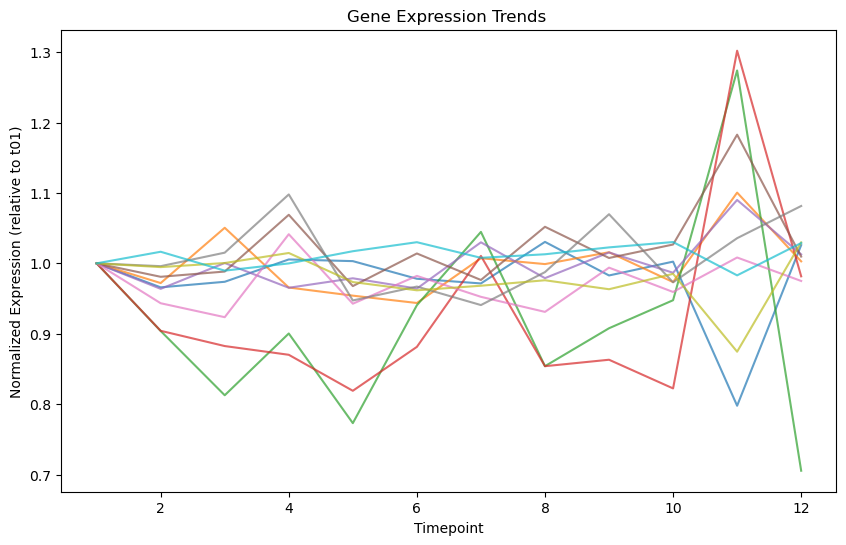

In [225]:
import matplotlib.pyplot as plt

genes_sample = one_subj["ID_REF"].unique()[:10]

plt.figure(figsize=(10,6))

for gene in genes_sample:
    gene_data = one_subj[one_subj["ID_REF"] == gene]
    plt.plot(gene_data["timepoint"], gene_data["norm_expr"], alpha=0.7)

plt.xlabel("Timepoint")
plt.ylabel("Normalized Expression (relative to t01)")
plt.title("Gene Expression Trends ")
plt.show()

In [227]:
meta[["title", "characteristics"]].drop_duplicates().head(20)

,title,characteristics
0,Control subject 6045 blood collection 01 [D9],timepoint: t01
1,Control subject 6045 blood collection 02 [D9],timepoint: t02
2,Control subject 6045 blood collection 03 [D9],timepoint: t03
3,Control subject 6045 blood collection 04 [D9],timepoint: t04
4,Control subject 6045 blood collection 08 [D9],timepoint: t05
5,Control subject 6045 blood collection 09 [D9],timepoint: t06
6,Control subject 6045 blood collection 11 [D9],timepoint: t08
7,Control subject 6045 blood collection 12 [D9],timepoint: t09
8,Control subject 6045 blood collection 13 [D9],timepoint: t10
9,Control subject 6045 blood collection 14 [D9],timepoint: t11


In [229]:
import numpy as np

poly_results = []

for (gene, subject), group in case_trend.groupby(["ID_REF", "subject"]):
    
    if len(group) >= 5:  # need enough points for quadratic
        x = group["timepoint"].values
        y = group["norm_expr"].values
        
        # Fit quadratic: y = a + b*x + c*x^2
        coeffs = np.polyfit(x, y, 2)
        a, b, c = coeffs
        
        poly_results.append((gene, subject, b, c))

poly_df = pd.DataFrame(poly_results, columns=[
    "ID_REF", "subject", "linear_coef", "quadratic_coef"
])

print(poly_df.head())
print(poly_df.shape)

    ID_REF subject  linear_coef  quadratic_coef
0  7896742    6166     0.007708        0.975678
1  7896742    6207    -0.025918        1.077950
2  7896742    6212     0.022767        0.955136
3  7896742    6291     0.010247        0.997135
4  7896742    6307    -0.058171        1.019558
(51036, 4)
